# Аналитика завершенных торгов — investmoscow.ru

Данные: завершенные торги за 2025–2026 гг. по нежилым помещениям Москвы.

## Загрузка и подготовка данных

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.size'] = 11
plt.rcParams['figure.figsize'] = (12, 6)

CSV_PATH = Path('data/investmoscow_completed_2026-04-04.csv')
CHARTS_DIR = Path('data/charts')
CHARTS_DIR.mkdir(exist_ok=True)

df = pd.read_csv(CSV_PATH, encoding='utf-8-sig')
print(f'Загружено: {len(df)} записей')

Загружено: 2839 записей


### Преобразование типов

In [2]:
def clean_num(s):
    if pd.isna(s) or s == '':
        return np.nan
    s = str(s).replace('\xa0', '').replace(' ', '')
    s = s.replace('руб.', '').replace('руб', '').replace('₽', '')
    s = s.replace(',', '.').strip()
    try:
        return float(s)
    except:
        return np.nan

df['start_price'] = pd.to_numeric(df['начальная_цена_руб'], errors='coerce')
df['final_price'] = df['итоговая_цена_руб'].apply(clean_num)
df['deposit'] = df['размер_задатка_руб'].apply(clean_num)
df['bid_step'] = df['шаг_аукциона_руб'].apply(clean_num)
df['price_per_m2'] = pd.to_numeric(df['цена_за_м²'], errors='coerce')
df['area'] = pd.to_numeric(df['площадь_м²'], errors='coerce')
df['floors'] = pd.to_numeric(df['этажность'], errors='coerce')
df['exceedance'] = df['превышение_цены_%'].apply(
    lambda x: clean_num(str(x).replace('%', '')) if pd.notna(x) and x != '' else np.nan
)
df['year'] = pd.to_numeric(df['год_торгов'], errors='coerce').astype('Int64')
df['request_end'] = pd.to_datetime(df['дата_окончания_приёма'], format='%d.%m.%Y %H:%M:%S', errors='coerce')
df['month'] = df['request_end'].dt.to_period('M')

# Округ
district_map = {
    'Центральный административный округ': 'ЦАО',
    'Северный административный округ': 'САО',
    'Северо-Восточный административный округ': 'СВАО',
    'Восточный административный округ': 'ВАО',
    'Юго-Восточный административный округ': 'ЮВАО',
    'Южный административный округ': 'ЮАО',
    'Юго-Западный административный округ': 'ЮЗАО',
    'Западный административный округ': 'ЗАО',
    'Северо-Западный административный округ': 'СЗАО',
    'Зеленоградский административный округ': 'ЗелАО',
    'Новомосковский административный округ': 'НАО',
    'Троицкий административный округ': 'ТАО',
}

def extract_district(addr):
    if pd.isna(addr):
        return 'Неизвестно'
    ao_match = re.search(r'([А-Я]{2,3}АО)', addr)
    if ao_match:
        return ao_match.group(1)
    full_match = re.search(r'([А-Яа-яё\s]+административный округ)', addr)
    if full_match:
        return full_match.group(1).strip()
    return 'Неизвестно'

df['district_short'] = df['адрес'].apply(extract_district)
df['district_short'] = df['district_short'].replace(district_map)

# Этаж — категория
def floor_category(floor):
    if pd.isna(floor):
        return 'Не указан'
    f = str(floor).lower().strip()
    if 'подвал' in f: return 'Подвал'
    if 'цокол' in f: return 'Цоколь'
    if f == '1': return '1 этаж'
    if f == '2': return '2 этаж'
    return '3+ этаж'

df['floor_cat'] = df['этаж'].apply(floor_category)

with_final = df[df['final_price'].notna()]
with_exceed = df[df['exceedance'].notna()]

print(f'С итоговыми ценами: {len(with_final)}')
print(f'С превышением: {len(with_exceed)}')

С итоговыми ценами: 1393
С превышением: 1393


---
## 1. Общая статистика

In [3]:
print('='*60)
print('ОБЩАЯ СТАТИСТИКА')
print('='*60)
print(f"Всего завершенных торгов: {len(df):,}")
print(f"  2025 год: {(df['year'] == 2025).sum():,}")
print(f"  2026 год: {(df['year'] == 2026).sum():,}")
print(f"С известной итоговой ценой: {len(with_final):,} ({len(with_final)/len(df)*100:.1f}%)")
print(f"Без итоговой цены: {len(df) - len(with_final):,}")
print(f"\nПлощадь (м²): среднее={df['area'].mean():.1f}, медиана={df['area'].median():.1f}")
print(f"Начальная цена: среднее={df['start_price'].mean()/1e6:.1f} млн, медиана={df['start_price'].median()/1e6:.1f} млн")
if len(with_final) > 0:
    print(f"Итоговая цена: среднее={with_final['final_price'].mean()/1e6:.1f} млн, медиана={with_final['final_price'].median()/1e6:.1f} млн")
if len(with_exceed) > 0:
    print(f"\nПревышение цены:")
    print(f"  Среднее: {with_exceed['exceedance'].mean():.1f}%")
    print(f"  Выше старта: {(with_exceed['exceedance'] > 0).sum()} ({(with_exceed['exceedance'] > 0).mean()*100:.1f}%)")
    print(f"  Ниже старта: {(with_exceed['exceedance'] < 0).sum()} ({(with_exceed['exceedance'] < 0).mean()*100:.1f}%)")
    print(f"  Без изменений: {(with_exceed['exceedance'] == 0).sum()}")

ОБЩАЯ СТАТИСТИКА
Всего завершенных торгов: 2,839
  2025 год: 2,226
  2026 год: 613
С известной итоговой ценой: 1,393 (49.1%)
Без итоговой цены: 1,446

Площадь (м²): среднее=169.9, медиана=102.7
Начальная цена: среднее=25.4 млн, медиана=18.4 млн
Итоговая цена: среднее=28.1 млн, медиана=21.8 млн

Превышение цены:
  Среднее: 30.5%
  Выше старта: 883 (63.4%)
  Ниже старта: 54 (3.9%)
  Без изменений: 456


---
## 2. Динамика торгов по месяцам

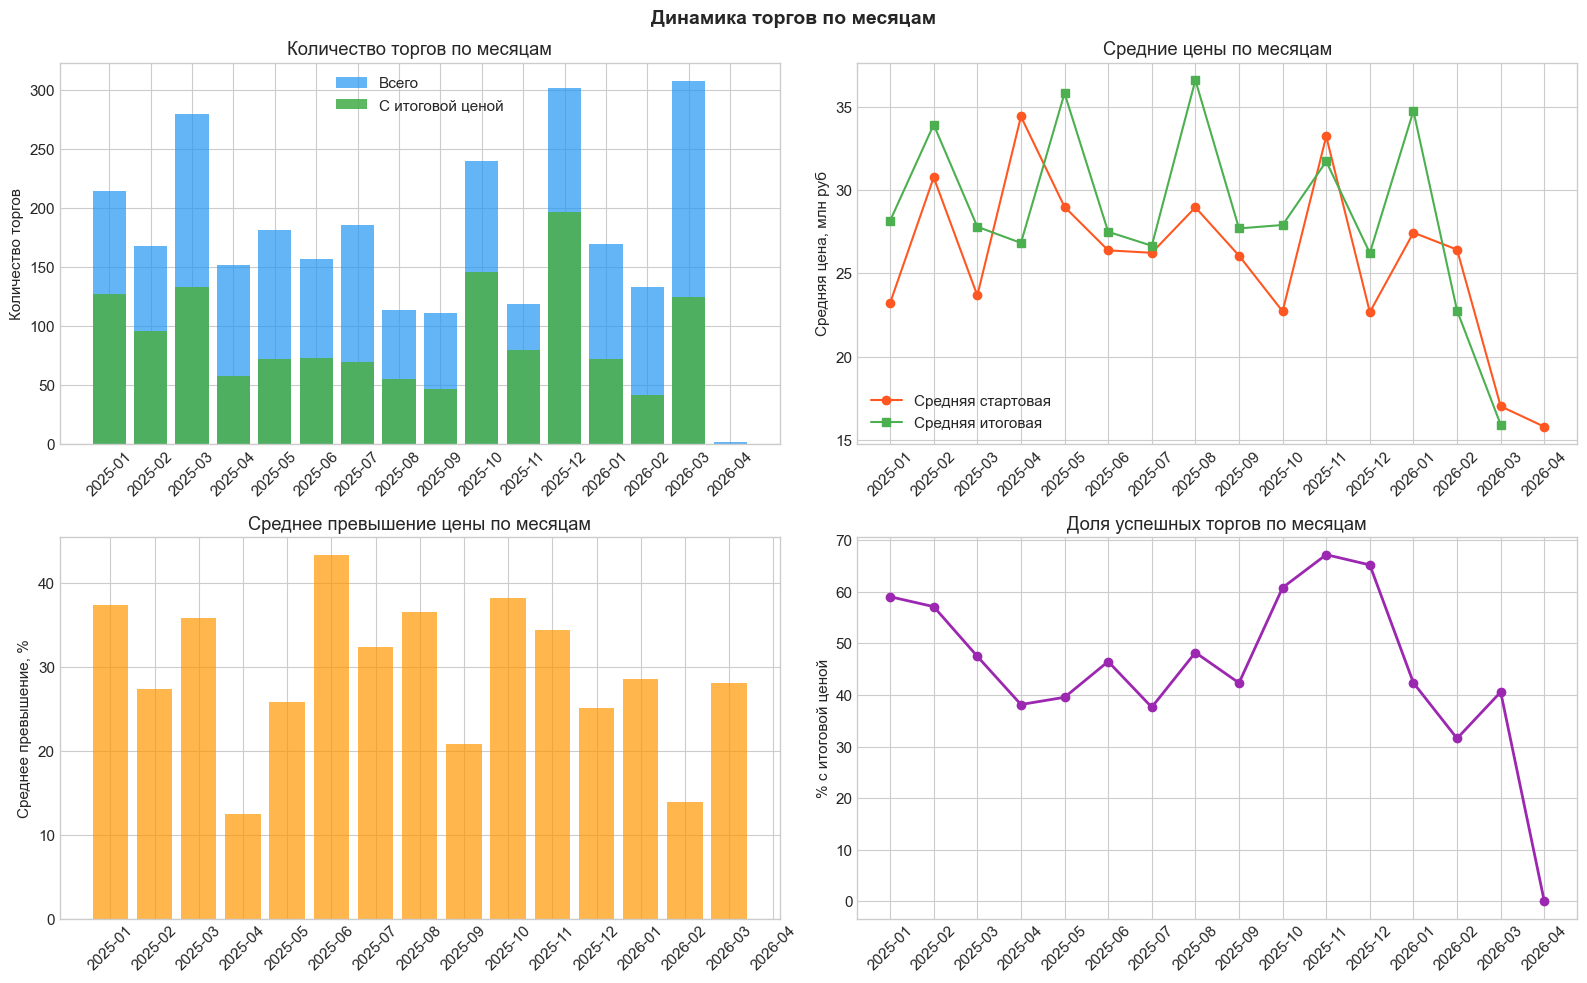

Сохранено: data\charts\monthly_dynamics.png


In [4]:
monthly = df.groupby('month').agg(
    total=('номер_лота', 'count'),
    with_final=('final_price', lambda x: x.notna().sum()),
    avg_start=('start_price', 'mean'),
    avg_final=('final_price', 'mean'),
    avg_exceedance=('exceedance', 'mean'),
).reset_index()
monthly['month_str'] = monthly['month'].astype(str)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Динамика торгов по месяцам', fontsize=14, fontweight='bold')

ax = axes[0, 0]
ax.bar(monthly['month_str'], monthly['total'], alpha=0.7, label='Всего', color='#2196F3')
ax.bar(monthly['month_str'], monthly['with_final'], alpha=0.9, label='С итоговой ценой', color='#4CAF50')
ax.set_ylabel('Количество торгов')
ax.set_title('Количество торгов по месяцам')
ax.legend()
ax.tick_params(axis='x', rotation=45)

ax = axes[0, 1]
ax.plot(monthly['month_str'], monthly['avg_start']/1e6, 'o-', label='Средняя стартовая', color='#FF5722')
ax.plot(monthly['month_str'], monthly['avg_final']/1e6, 's-', label='Средняя итоговая', color='#4CAF50')
ax.set_ylabel('Средняя цена, млн руб')
ax.set_title('Средние цены по месяцам')
ax.legend()
ax.tick_params(axis='x', rotation=45)

ax = axes[1, 0]
ax.bar(monthly['month_str'], monthly['avg_exceedance'], alpha=0.7, color='#FF9800')
ax.axhline(y=0, color='black', linewidth=0.5)
ax.set_ylabel('Среднее превышение, %')
ax.set_title('Среднее превышение цены по месяцам')
ax.tick_params(axis='x', rotation=45)

ax = axes[1, 1]
ax.plot(monthly['month_str'], monthly['with_final']/monthly['total']*100, 'o-', color='#9C27B0', linewidth=2)
ax.set_ylabel('% с итоговой ценой')
ax.set_title('Доля успешных торгов по месяцам')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(CHARTS_DIR/'monthly_dynamics.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Сохранено: {CHARTS_DIR/"monthly_dynamics.png"}')

---
## 3. Анализ по округам Москвы

In [5]:
district_stats = df.groupby('district_short').agg(
    count=('номер_лота', 'count'),
    avg_area=('area', 'mean'),
    avg_start=('start_price', 'mean'),
    avg_price_per_m2=('price_per_m2', 'mean'),
    success_rate=('final_price', lambda x: x.notna().sum()/len(x)*100),
    avg_exceedance=('exceedance', 'mean'),
).sort_values('count', ascending=False)

print('Статистика по округам:')
print(district_stats.to_string())

Статистика по округам:
                count    avg_area     avg_start  avg_price_per_m2  success_rate  avg_exceedance
district_short                                                                                 
Неизвестно        769   96.993628  2.313323e+07     243181.835007     64.109233       35.333671
ВАО               625  238.861280  2.662005e+07     154511.926800     43.040000       26.063197
ЗАО               608  169.028125  2.593565e+07     169272.826530     42.434211       29.563953
САО               320  157.189687  2.065032e+07     169017.857969     43.437500       21.808633
ЦАО               257  237.115953  3.742833e+07     202750.759222     50.194553       40.131783
ЮАО               193  171.811399  2.235785e+07     160223.026684     44.041451       24.135294
ЗелАО              44  172.877273  2.181504e+07     131209.351364     31.818182        6.964286
НАО                18  171.555556  2.497053e+07     151729.125000     22.222222       28.000000
ТАО              

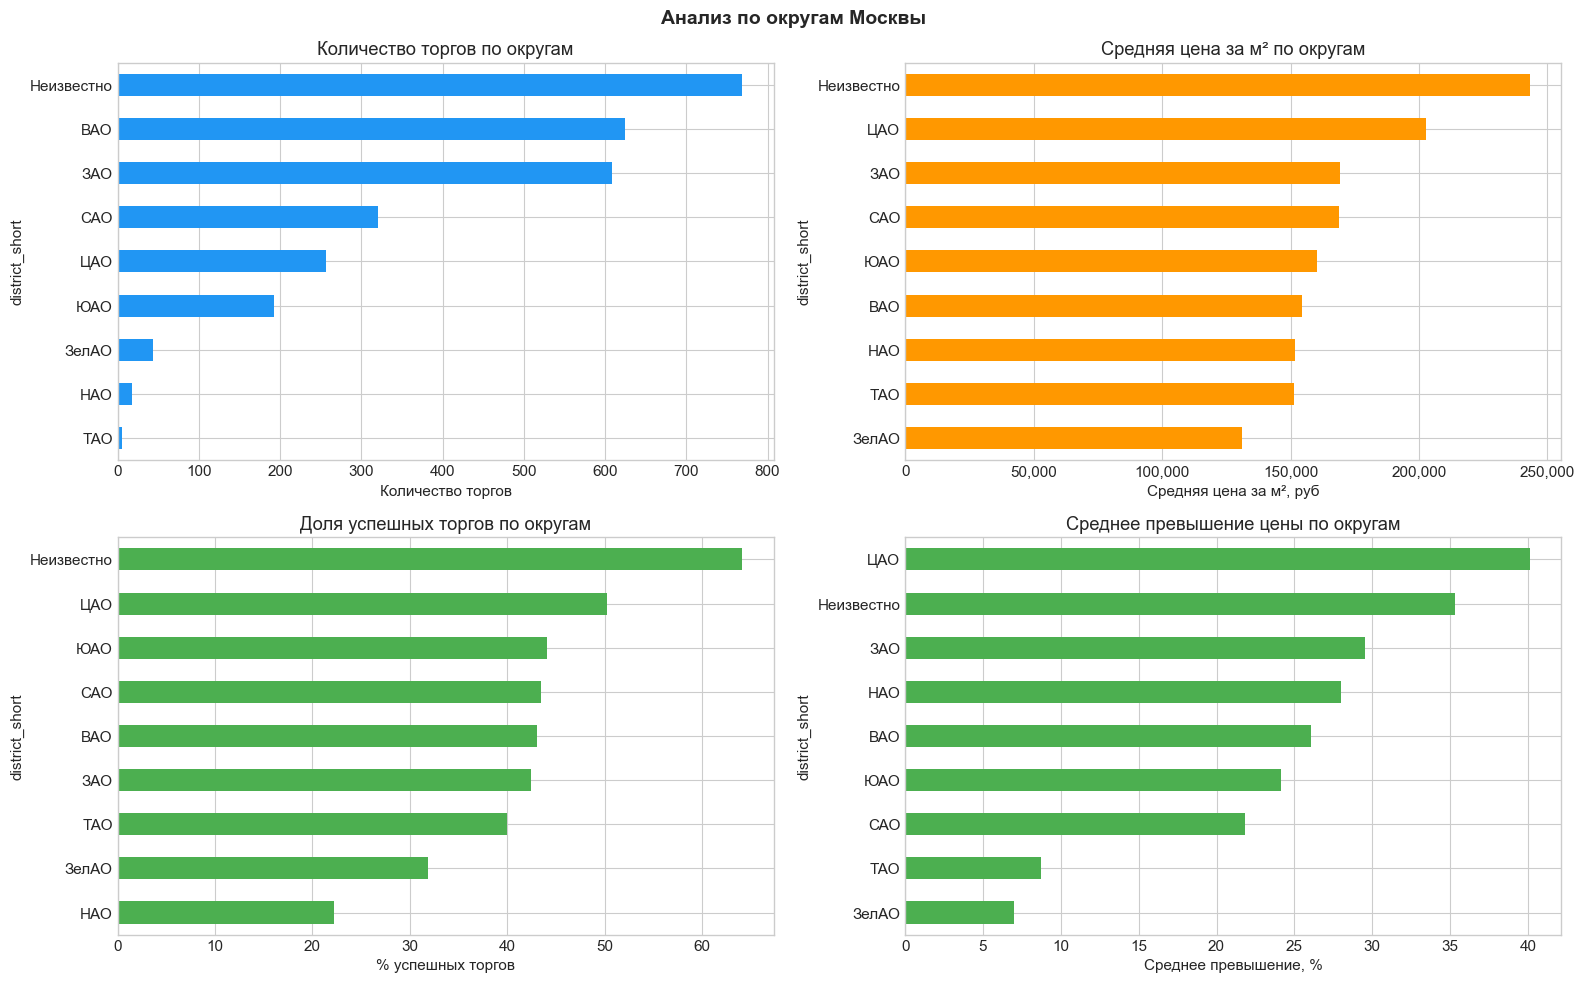

Сохранено: data\charts\district_analysis.png


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Анализ по округам Москвы', fontsize=14, fontweight='bold')

ax = axes[0, 0]
district_stats['count'].sort_values(ascending=True).plot(kind='barh', ax=ax, color='#2196F3')
ax.set_xlabel('Количество торгов')
ax.set_title('Количество торгов по округам')

ax = axes[0, 1]
avg_ppm = district_stats['avg_price_per_m2'].dropna().sort_values(ascending=True)
avg_ppm.plot(kind='barh', ax=ax, color='#FF9800')
ax.set_xlabel('Средняя цена за м², руб')
ax.set_title('Средняя цена за м² по округам')
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

ax = axes[1, 0]
sr = district_stats['success_rate'].sort_values(ascending=True)
sr.plot(kind='barh', ax=ax, color='#4CAF50')
ax.set_xlabel('% успешных торгов')
ax.set_title('Доля успешных торгов по округам')

ax = axes[1, 1]
exc = district_stats['avg_exceedance'].dropna().sort_values(ascending=True)
colors = ['#F44336' if v < 0 else '#4CAF50' for v in exc]
exc.plot(kind='barh', ax=ax, color=colors)
ax.set_xlabel('Среднее превышение, %')
ax.set_title('Среднее превышение цены по округам')
ax.axvline(x=0, color='black', linewidth=0.5)

plt.tight_layout()
plt.savefig(CHARTS_DIR/'district_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Сохранено: {CHARTS_DIR/"district_analysis.png"}')

---
## 4. Распределение цен

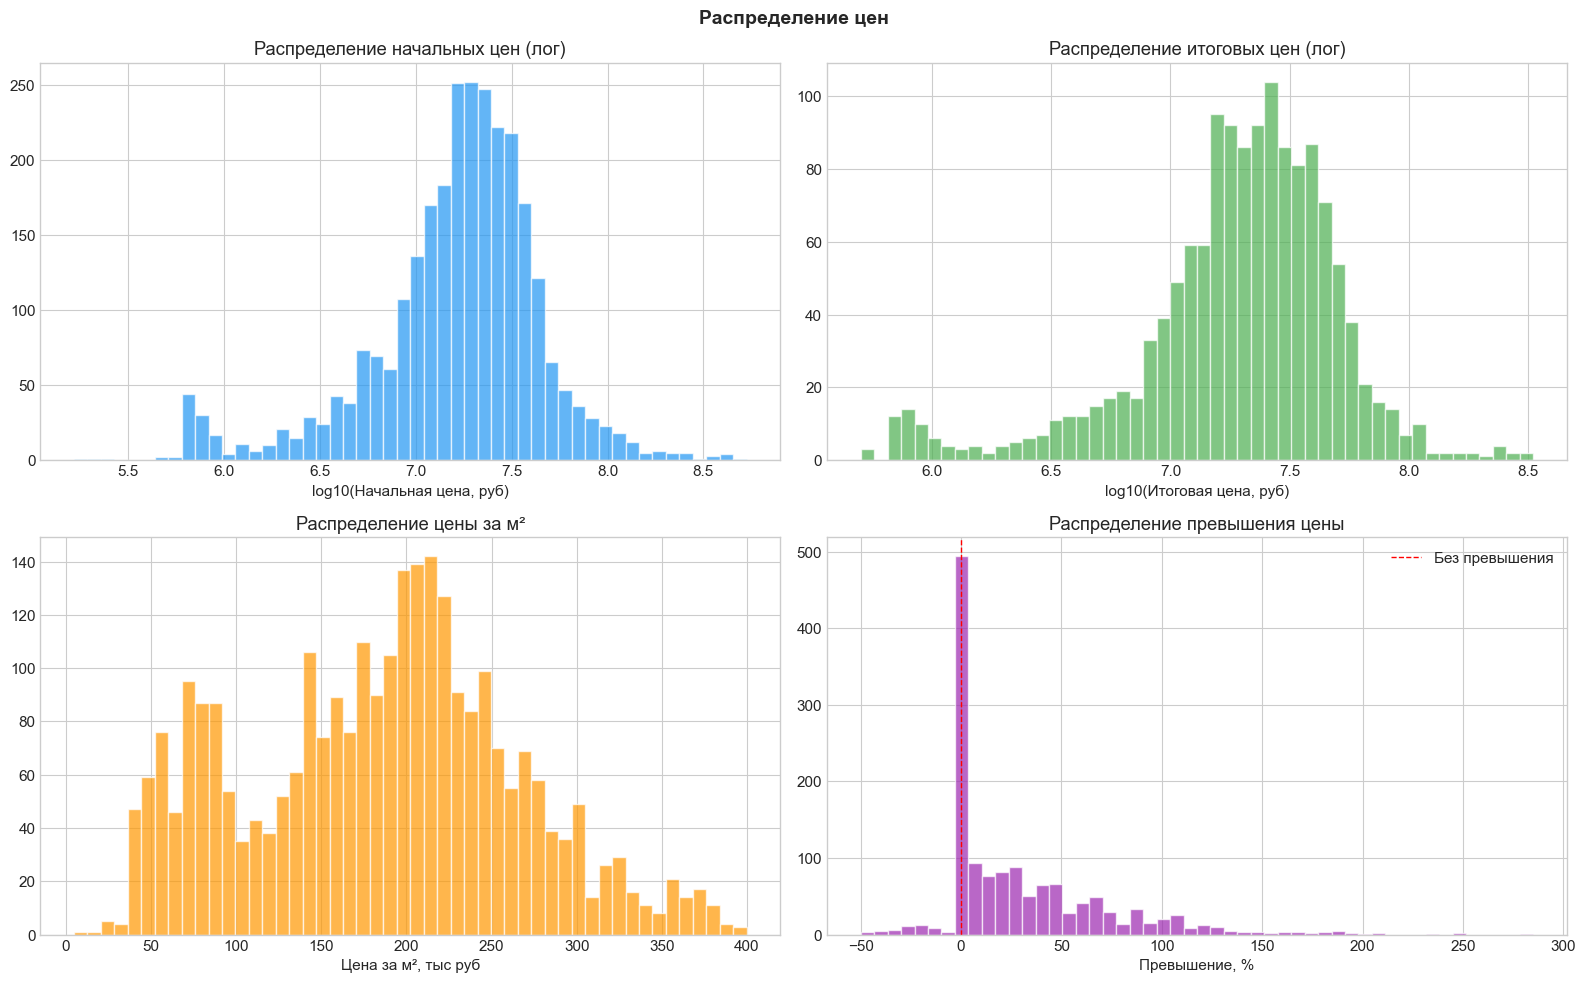

Сохранено: data\charts\price_distribution.png


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Распределение цен', fontsize=14, fontweight='bold')

ax = axes[0, 0]
vs = df['start_price'].dropna()
vs = vs[vs > 0]
ax.hist(np.log10(vs), bins=50, alpha=0.7, color='#2196F3', edgecolor='white')
ax.set_xlabel('log10(Начальная цена, руб)')
ax.set_title('Распределение начальных цен (лог)')

ax = axes[0, 1]
vf = df['final_price'].dropna()
vf = vf[vf > 0]
ax.hist(np.log10(vf), bins=50, alpha=0.7, color='#4CAF50', edgecolor='white')
ax.set_xlabel('log10(Итоговая цена, руб)')
ax.set_title('Распределение итоговых цен (лог)')

ax = axes[1, 0]
vppm = df['price_per_m2'].dropna()
vppm = vppm[vppm > 0]
q99 = vppm.quantile(0.99)
vppm = vppm[vppm <= q99]
ax.hist(vppm/1000, bins=50, alpha=0.7, color='#FF9800', edgecolor='white')
ax.set_xlabel('Цена за м², тыс руб')
ax.set_title('Распределение цены за м²')

ax = axes[1, 1]
ve = df['exceedance'].dropna()
ax.hist(ve, bins=50, alpha=0.7, color='#9C27B0', edgecolor='white')
ax.axvline(x=0, color='red', linestyle='--', linewidth=1, label='Без превышения')
ax.set_xlabel('Превышение, %')
ax.set_title('Распределение превышения цены')
ax.legend()

plt.tight_layout()
plt.savefig(CHARTS_DIR/'price_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Сохранено: {CHARTS_DIR/"price_distribution.png"}')

---
## 5. Анализ по этажам

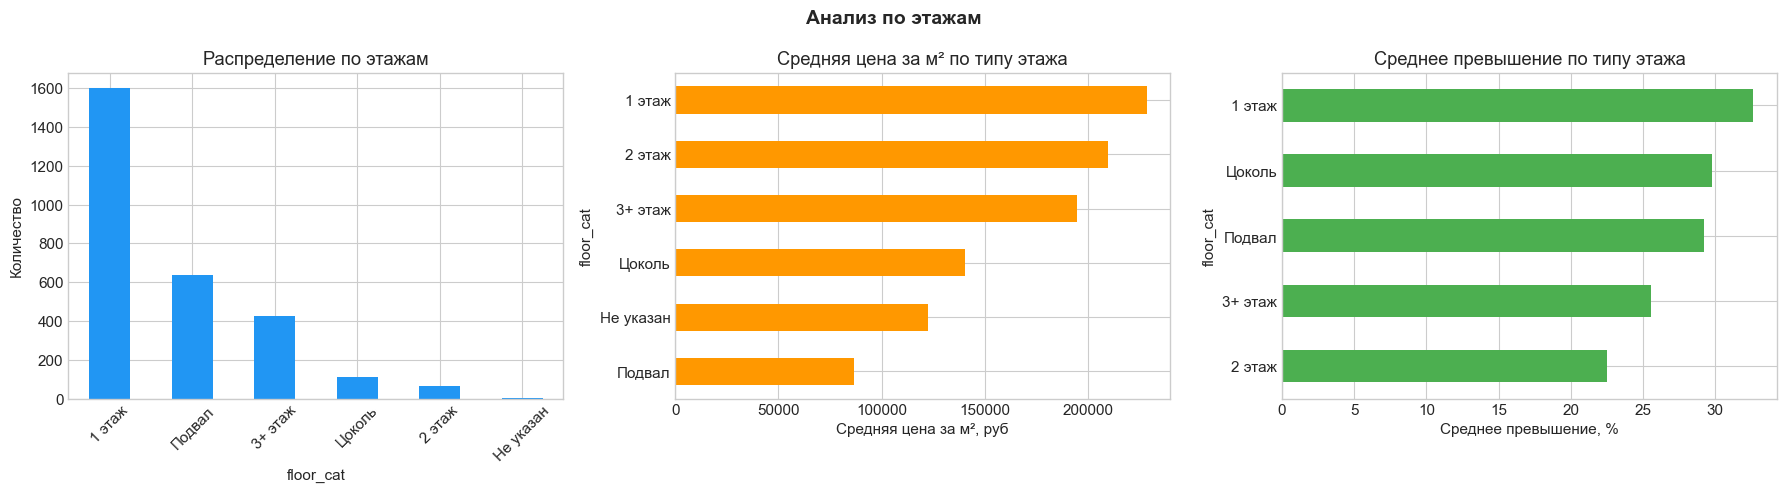

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Анализ по этажам', fontsize=14, fontweight='bold')

ax = axes[0]
df['floor_cat'].value_counts().plot(kind='bar', ax=ax, color='#2196F3')
ax.set_ylabel('Количество')
ax.set_title('Распределение по этажам')
ax.tick_params(axis='x', rotation=45)

ax = axes[1]
df.groupby('floor_cat')['price_per_m2'].mean().dropna().sort_values(ascending=True).plot(kind='barh', ax=ax, color='#FF9800')
ax.set_xlabel('Средняя цена за м², руб')
ax.set_title('Средняя цена за м² по типу этажа')

ax = axes[2]
floor_exc = df.groupby('floor_cat')['exceedance'].mean().dropna().sort_values(ascending=True)
floor_exc.plot(kind='barh', ax=ax, color='#4CAF50')
ax.set_xlabel('Среднее превышение, %')
ax.set_title('Среднее превышение по типу этажа')
ax.axvline(x=0, color='black', linewidth=0.5)

plt.tight_layout()
plt.savefig(CHARTS_DIR/'floor_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Топ самых конкурентных торгов

In [9]:
top_comp = df[df['exceedance'].notna()].nlargest(15, 'exceedance')
print('Топ-15 самых конкурентных торгов:')
for _, row in top_comp.iterrows():
    addr = str(row['адрес'])[:50]
    print(f"Лот {row['номер_лота']:>12} | {addr:<55} | {row['area']:>7.1f} м² | "
          f"{row['start_price']:>12,.0f} → {row['final_price']:>12,.0f} | {row['exceedance']:>+7.1f}%")

Топ-15 самых конкурентных торгов:
Лот     19724315 | Центральный административный округ, Пресненский, Б      |    45.1 м² |    6,451,000 →   24,836,350 |  +285.0%
Лот     19947408 | Южный административный округ, Чертаново Южное, Вар      |    33.9 м² |    3,654,000 →   12,789,000 |  +250.0%
Лот     19758282 | Восточный административный округ, Измайлово, Завод      |    39.7 м² |    1,950,000 →    6,727,500 |  +245.0%
Лот     19863559 | Очаковское шоссе, дом 7, этаж 1, пом. 62Н               |   105.6 м² |   25,597,000 →   85,110,025 |  +232.5%
Лот     19866586 | Западный административный округ, Солнцево, Солнцев      |    51.6 м² |   13,350,000 →   41,385,000 |  +210.0%
Лот     19863548 | Очаковское шоссе, дом 7, этаж 1, пом. 53Н               |    71.7 м² |   18,450,000 →   56,364,750 |  +205.5%
Лот     19992535 | Очаковское шоссе, дом 7, этаж 1, пом. 128Н              |    52.5 м² |   14,171,000 →   42,442,145 |  +199.5%
Лот     19885093 | Очаковское шоссе, дом 7, этаж 1, пом. 128Н  

---
## 7. Ключевые выводы

In [10]:
print('='*60)
print('КЛЮЧЕВЫЕ ВЫВОДЫ')
print('='*60)

total_start = df['start_price'].sum()
total_final = with_final['final_price'].sum() if len(with_final) > 0 else 0
print(f"\n1. ОБЪЁМ РЫНКА")
print(f"   Общая начальная стоимость: {total_start/1e9:.1f} млрд руб")
print(f"   Общая итоговая стоимость: {total_final/1e9:.1f} млрд руб")
print(f"   Допродано сверх старта: {(total_final - total_start)/1e9:+.1f} млрд руб")

if len(with_exceed) > 0:
    hot = (with_exceed['exceedance'] >= 50).sum()
    very_hot = (with_exceed['exceedance'] >= 100).sum()
    print(f"\n2. КОНКУРЕНТНОСТЬ")
    print(f"   {hot} лотов ушли с превышением >=50% от стартовой цены")
    print(f"   {very_hot} лотов ушли с превышением >=100% (удвоение и более)")

bd = district_stats['avg_exceedance'].dropna().idxmax()
wd = district_stats['avg_exceedance'].dropna().idxmin()
print(f"\n3. ОКРУГА")
print(f"   Самое высокое превышение: {bd} ({district_stats.loc[bd, 'avg_exceedance']:.1f}%)")
print(f"   Самое низкое превышение: {wd} ({district_stats.loc[wd, 'avg_exceedance']:.1f}%)")

if len(floor_exc) > 0:
    print(f"\n4. ЭТАЖИ")
    print(f"   Наибольшее среднее превышение: {floor_exc.idxmax()} ({floor_exc.max():.1f}%)")
    print(f"   Наименьшее: {floor_exc.idxmin()} ({floor_exc.min():.1f}%)")

print(f"\n5. НЕСОСТОЯВШИЕСЯ ТОРГИ")
print(f"   {len(df)-len(with_final):,} лотов ({(len(df)-len(with_final))/len(df)*100:.1f}%) не имели итоговой цены")

print(f"\n{'='*60}")

КЛЮЧЕВЫЕ ВЫВОДЫ

1. ОБЪЁМ РЫНКА
   Общая начальная стоимость: 72.2 млрд руб
   Общая итоговая стоимость: 39.1 млрд руб
   Допродано сверх старта: -33.2 млрд руб

2. КОНКУРЕНТНОСТЬ
   350 лотов ушли с превышением >=50% от стартовой цены
   113 лотов ушли с превышением >=100% (удвоение и более)

3. ОКРУГА
   Самое высокое превышение: ЦАО (40.1%)
   Самое низкое превышение: ЗелАО (7.0%)

4. ЭТАЖИ
   Наибольшее среднее превышение: 1 этаж (32.7%)
   Наименьшее: 2 этаж (22.5%)

5. НЕСОСТОЯВШИЕСЯ ТОРГИ
   1,446 лотов (50.9%) не имели итоговой цены

